# 10 Un modele par propriete, et le boosting

**Auteur : Jules Mortreux. Branche : `explo-jules`.**

Les notebooks 02 a 09 predisent tous **un score unique** qui agrege plusieurs
proprietes mecaniques en un nombre entre 0 et 1. Ce notebook explore une
approche differente : **predire chaque propriete separement**, puis recomposer le
score si besoin.

Il ajoute aussi au projet la seule famille de modeles qui manquait, le
**boosting**, et la teste a la fois sur les proprietes individuelles et sur le
score agrege, afin que tout soit comparable.

## Pourquoi cette question se pose

Le score du notebook 08 repond bien a la question de l'enonce, qui est de
predire la qualite d'une soudure. Mais il a un defaut qu'un exemple montre
mieux qu'une explication.

Voici deux soudures du jeu de developpement qui recoivent **le meme score de
0,48**, donc que nos modeles declarent equivalentes :

| | limite d'elasticite | resistance | allongement | striction |
|---|---|---|---|---|
| `Blond-1984-14MNDV5b` | **663 MPa** | **730 MPa** | 22,5 % | 66,5 % |
| `Evans-StressRelief-1991-0.095B` | 435 MPa | 546 MPa | **34,0 %** | **77,0 %** |

Deux cent vingt-huit megapascals d'ecart en limite d'elasticite, et onze points
et demi d'allongement. La premiere est dure et peu deformable, la seconde est
souple et tres ductile. Ce sont deux produits differents, pour deux usages
differents, et le score les confond.

La raison est structurelle : **resistance et ductilite sont negativement
correlees**, jusqu'a -0,76 entre la resistance et l'allongement. Un score qui
agrege deux grandeurs opposees indique le **niveau** du compromis mais pas la
**position** sur ce compromis.

## Les quatre arguments en faveur d'un modele par propriete

**Il conserve l'information.** Avec les quatre predictions on peut toujours
recalculer le score ; l'inverse est impossible. L'approche par propriete
englobe donc l'approche par score plutot que de s'y opposer.

**Il predit en unites physiques.** Annoncer 520 MPa et 28 % d'allongement parle
directement a un metallurgiste. Annoncer 0,48 demande une table de
correspondance.

**Il recupere des donnees.** C'est l'argument le plus concret, et il decoule
directement du notebook 01 : les valeurs manquantes suivent le protocole
experimental, donc tous les laboratoires ne mesurent pas les quatre proprietes.
Exiger les quatre simultanement, comme le fait le score, coute des lignes que
chaque modele dedie peut recuperer. La section 1 le quantifie.

**Chaque propriete a ses propres determinants.** La section 4.4 du notebook 08
l'avait montre : la resistance est gouvernee par les elements d'alliage, la
tenacite par l'oxygene et l'azote. Un modele unique force de predire un melange
des deux fait un compromis sur ses propres reglages ; quatre modeles peuvent
chacun avoir les leurs.

## Les deux objections, annoncees d'avance

**Chaque propriete sera plus bruitee que le score.** La section 4 du notebook 08
a etabli que le score est mieux predit que ses composantes individuelles parce
que moyenner deux mesures reduit le bruit propre a chaque essai. Un modele sur
une mesure brute affronte ce bruit en entier.

**L'evaluation devient multidimensionnelle.** Avec quatre nombres, affirmer
qu'un modele est meilleur qu'un autre exige quand meme un critere de synthese.
On ne se debarrasse donc pas du score, on le deplace : il cesse d'etre la cible
et devient un indicateur calcule a partir des predictions.

Et une question qui ne se tranche que par l'experience, a laquelle la section 6
repond : **predire les quatre proprietes puis agreger donne-t-il un meilleur
score que predire le score directement ?** Les erreurs peuvent se composer ou
se compenser, rien ne permet de le deviner.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as version_sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (BaggingRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, ParameterGrid
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                   StandardScaler)
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "outputs" / "10"
OUT.mkdir(parents=True, exist_ok=True)

GRAINE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
pd.set_option("display.max_colwidth", None)
print("scikit-learn", version_sklearn)
print("sorties dans", OUT.relative_to(ROOT))

scikit-learn 1.7.2
sorties dans outputs\10


## 1. Les donnees, et ce que chaque modele dedie recupere

On repart des donnees nettoyees du notebook 01, et non du fichier produit par le
notebook 08. La raison est exactement celle annoncee : le fichier du notebook 08
ne contient que les lignes ou les **quatre** proprietes sont mesurees, alors que
chaque modele dedie peut travailler sur son propre domaine.

La separation developpement/test est reconstruite a l'identique, avec la meme
graine et la meme methode, puis verifiee contre celle du notebook 02.

In [2]:
colonnes_texte = ["AC_DC", "Electrode_pol", "WeldType", "WeldID",
                  "hardness_scale"]
propre = pd.read_csv(PROCESSED / "welddb_clean.csv", index_col="row_id",
                     dtype={c: str for c in colonnes_texte},
                     keep_default_na=False, na_values=[""],
                     float_precision="round_trip")
groupes = pd.read_csv(PROCESSED / "welddb_groups.csv",
                      index_col="row_id")["groupe"]
schema = json.loads((PROCESSED / "welddb_metadata.json").read_text())["schema"]

RESISTANCE = ["YieldStrength_MPa", "UTS_MPa"]
DUCTILITE = ["Elongation_pct", "ReductionArea_pct"]
PROPRIETES = RESISTANCE + DUCTILITE
UNITES = {"YieldStrength_MPa": "MPa", "UTS_MPa": "MPa",
          "Elongation_pct": "%", "ReductionArea_pct": "%"}
NOMS_LISIBLES = {"YieldStrength_MPa": "limite d'elasticite",
                 "UTS_MPa": "resistance a la traction",
                 "Elongation_pct": "allongement",
                 "ReductionArea_pct": "striction"}

VARIABLES = schema["COMPOSITION"] + schema["PROCESS"]
CATEGORIES = ["AC_DC", "Electrode_pol", "WeldType"]
assert not set(PROPRIETES) & set(VARIABLES)

# Meme separation que tous les notebooks precedents.
indices_dev, _ = next(GroupShuffleSplit(n_splits=1, test_size=0.20,
                                        random_state=GRAINE)
                      .split(propre, groups=groupes))
partition = pd.Series("test", index=propre.index, name="partition")
partition.iloc[indices_dev] = "developpement"
dev = partition == "developpement"

reference_partition = pd.read_csv(ROOT / "outputs/02/dataset_traction.csv",
                                  index_col="row_id")["partition"]
assert (partition.loc[reference_partition.index]
        == reference_partition).all(), "partition differente du notebook 02"
print("Partition identique a celle du notebook 02.")
print(f"{len(VARIABLES)} variables d'entree, "
      f"{int(dev.sum())} lignes de developpement.")

Partition identique a celle du notebook 02.
30 variables d'entree, 1298 lignes de developpement.


In [3]:
jeu_y3 = pd.read_csv(ROOT / "outputs/08/dataset_traction_y3.csv",
                     index_col="row_id")
lignes_y3_dev = jeu_y3.index[jeu_y3["partition"] == "developpement"]

lignes_domaines = []
for propriete in PROPRIETES:
    disponible = propre[propriete].notna() & dev
    lignes_domaines.append({
        "propriete": NOMS_LISIBLES[propriete],
        "unite": UNITES[propriete],
        "lignes": int(disponible.sum()),
        "soudures": groupes[disponible].nunique(),
        "mediane": propre.loc[disponible, propriete].median(),
        "ecart-type": propre.loc[disponible, propriete].std(),
    })
lignes_domaines.append({
    "propriete": "score y3 (les 4 ensemble)", "unite": "rang",
    "lignes": len(lignes_y3_dev),
    "soudures": groupes.loc[lignes_y3_dev].nunique(),
    "mediane": jeu_y3.loc[lignes_y3_dev, "score_compromis"].median(),
    "ecart-type": jeu_y3.loc[lignes_y3_dev, "score_compromis"].std(),
})

domaines = pd.DataFrame(lignes_domaines).set_index("propriete")
domaines["gain de lignes"] = (domaines["lignes"] / len(lignes_y3_dev) - 1)
domaines.loc["score y3 (les 4 ensemble)", "gain de lignes"] = 0.0
domaines.round(3)

,unite,lignes,soudures,mediane,ecart-type,gain de lignes
propriete,,,,,,
limite d'elasticite,MPa,635,456,492.000,95.379,0.205
resistance a la traction,MPa,599,428,571.000,91.327,0.137
allongement,%,566,400,27.000,4.950,0.074
striction,%,573,408,75.000,9.294,0.087
score y3 (les 4 ensemble),rang,527,376,0.426,0.132,0.000


### Ce que le tableau montre

**Chaque modele dedie dispose de plus de donnees que le modele sur le score.**
Le gain va de quelques pourcents pour l'allongement a environ vingt pourcents
pour la limite d'elasticite. Ce n'est pas enorme mais ce n'est pas negligeable
sur un corpus de cette taille, et c'est gratuit : aucune donnee supplementaire
n'est collectee, on cesse simplement d'en jeter.

**Les ordres de grandeur rappellent pourquoi les RMSE ne seront pas
comparables entre proprietes.** Une resistance se compte en centaines de
megapascals, un allongement en dizaines de pourcents. Une erreur de 40 sur la
premiere et de 3 sur le second peuvent tres bien representer la meme difficulte.
Comme dans les notebooks 08 et 09, **toutes les comparaisons se feront sur le
gain par rapport a une reference constante**, qui est sans unite.

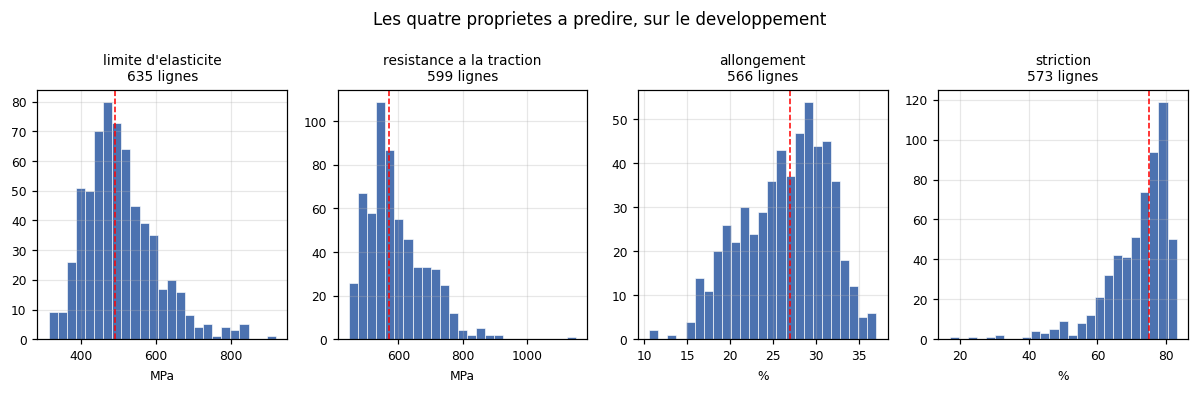

In [4]:
plt.figure(figsize=(11, 3.6))
for position, propriete in enumerate(PROPRIETES, start=1):
    axe = plt.subplot(1, 4, position)
    valeurs = propre.loc[propre[propriete].notna() & dev, propriete]
    axe.hist(valeurs, bins=25, color="#4C72B0", edgecolor="white",
             linewidth=0.4)
    axe.axvline(valeurs.median(), color="red", linestyle="--", linewidth=1)
    axe.set_title(f"{NOMS_LISIBLES[propriete]}\n{len(valeurs)} lignes",
                  fontsize=9)
    axe.set_xlabel(UNITES[propriete], fontsize=8)
    axe.tick_params(labelsize=8)
plt.suptitle("Les quatre proprietes a predire, sur le developpement",
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT / "distributions_proprietes.png", dpi=150)
plt.show()

## 2. Le boosting, puisque le cours ne le developpe pas

Le boosting est **cite** dans les transparents du cours, dans la liste des
methodes d'ensemble aux cotes du bagging et des forêts aleatoires, mais il n'y
est pas developpe. Comme ce notebook l'utilise, il faut l'expliquer, et surtout
dire en quoi il differe de ce que le cours a traite.

### Le principe

Le bagging et la forêt aleatoire construisent beaucoup d'arbres **en
parallele**, chacun sur un echantillon different, puis moyennent leurs
predictions. Les arbres ne se parlent pas.

Le boosting construit les arbres **en sequence**, et chaque nouvel arbre
travaille sur ce que les precedents n'ont pas reussi a expliquer. Dans sa
version pour la regression, cela s'ecrit tres simplement :

```
1. on part d'une prediction constante, la moyenne
2. on calcule les residus, c'est-a-dire ce qui reste a expliquer
3. on entraine un petit arbre a predire ces residus
4. on ajoute une FRACTION de cet arbre a la prediction courante
5. on retourne a l'etape 2
```

La fraction de l'etape 4 s'appelle le **taux d'apprentissage**. Elle est petite,
typiquement 0,05 ou 0,1, ce qui veut dire que chaque arbre ne corrige qu'un
dixieme de l'erreur restante. On avance donc par petits pas prudents, et il faut
beaucoup d'arbres.

### La difference de fond avec le bagging, que le cours ne dit pas

Le cours presente les methodes d'ensemble comme un moyen de **reduire la
variance** d'un arbre, qui est son defaut principal. C'est exact pour le bagging
et pour la forêt aleatoire : on moyenne des arbres profonds, peu biaises mais
instables, et la moyenne stabilise.

**Le boosting fait l'inverse.** Il part d'arbres volontairement tres peu
profonds, souvent deux ou trois niveaux, donc tres biaises mais tres stables, et
il **reduit le biais** en les empilant. C'est la deuxieme moitie du compromis
biais-variance, celle que le cours n'a pas illustree.

Cette difference a une consequence pratique importante.

### Le nombre d'arbres n'a pas le meme statut

Pour le bagging et la forêt, le notebook 05 a pu regler le nombre d'arbres
separement du reste, parce qu'en ajouter ne degrade jamais : cela fait seulement
converger la moyenne. Le nombre d'arbres n'est pas un parametre de compromis.

**Pour le boosting, il l'est pleinement.** Chaque arbre ajoute reduit l'erreur
d'apprentissage, donc au-dela d'un certain point le modele se met a apprendre le
bruit. Il existe un nombre d'arbres optimal, et le depasser degrade la
validation.

Pire, ce nombre optimal **depend du taux d'apprentissage** : avec des pas deux
fois plus petits il faut environ deux fois plus d'arbres pour la meme quantite
d'ajustement. Les deux parametres ne peuvent donc pas etre regles separement.

**Conclusion pour la grille : il faut explorer conjointement le taux
d'apprentissage et le nombre d'arbres.** On ne peut pas reutiliser la recherche
en deux etapes du notebook 05, et la section 3 explique comment la grille a ete
construite en consequence.

### Les deux implementations testees

Scikit-learn en propose deux, et on garde les deux pour pouvoir les comparer.

**`GradientBoostingRegressor`** est l'implementation classique, celle qui suit
litteralement l'algorithme ci-dessus. Elle est lente car entierement
sequentielle.

**`HistGradientBoostingRegressor`** est une version acceleree, qui regroupe
d'abord les valeurs de chaque variable en 255 intervalles avant de chercher les
coupures. Elle est beaucoup plus rapide, et elle a une propriete interessante
pour nous : **elle sait traiter les valeurs manquantes sans imputation**, en
apprenant de quel cote de chaque coupure envoyer les lignes dont la valeur est
absente. Avec 45,6 % de valeurs manquantes dans notre corpus, cela merite d'etre
teste, et la section 8 y est consacree.

## 3. Le protocole et les grilles

Tout est repris du notebook 09, de sorte que les resultats des deux notebooks
soient directement comparables.

- cinq plis par `GroupKFold` sur la colonne `groupe`, donc aucune soudure a
  cheval entre apprentissage et validation ;
- preparation reajustee dans chaque pli : selection des colonnes a 25 % de
  remplissage, imputation par la mediane, encodage one-hot, standardisation
  pour les modeles qui en ont besoin ;
- metriques ponderees pour qu'une soudure compte pour une ;
- graine 42 partout.

**Une difference avec le notebook 09, et une seule : la cible.** Ici elle est
une propriete mecanique brute, en megapascals ou en pourcents, et non un rang.
Il n'y a donc **aucun recalibrage a faire dans les plis**, puisqu'une valeur
mesuree ne depend pas de l'echantillon. Cela simplifie le protocole et supprime
au passage une source possible de fuite d'information.

**Les grilles sont celles des notebooks 05 et 06**, a l'identique, plus les deux
grilles de boosting. Pour ces dernieres, le taux d'apprentissage et le nombre
d'arbres sont explores conjointement, pour la raison expliquee en section 2.

In [5]:
def poids_groupes(groupes_echantillon):
    """Un poids total de 1 par soudure, reparti sur ses lignes."""
    effectifs = groupes_echantillon.map(groupes_echantillon.value_counts())
    return (1 / effectifs).to_numpy()


def creer_preparation(X_apprentissage, normaliser=False, n_axes=None,
                      indicateurs=False, natif=False, seuil=0.25):
    """Preparation des entrees, reprise des notebooks 03, 06 et 09.

    Avec natif=True, les valeurs numeriques manquantes ne sont pas imputees :
    elles sont transmises telles quelles au modele, ce que seul le boosting par
    histogrammes sait exploiter. Les categories sont alors encodees en entiers
    plutot qu'en one-hot, l'implementation acceptant ce format.
    """
    taux = X_apprentissage.notna().mean()
    gardees = taux[taux >= seuil].index.tolist()
    numeriques = [c for c in gardees if c not in CATEGORIES]
    categorielles = [c for c in gardees if c in CATEGORIES]

    if natif:
        return ColumnTransformer([
            ("nombres", "passthrough", numeriques),
            ("categories", Pipeline([
                ("manquants", SimpleImputer(strategy="constant",
                                            fill_value="manquant")),
                ("encodage", OrdinalEncoder(handle_unknown="use_encoded_value",
                                            unknown_value=-1)),
            ]), categorielles),
        ])

    etapes = [("mediane", SimpleImputer(strategy="median",
                                        add_indicator=indicateurs))]
    if normaliser:
        etapes.append(("standardisation", StandardScaler()))
    if n_axes is not None:
        etapes.append(("acp", PCA(n_components=min(n_axes, len(numeriques)),
                                  random_state=GRAINE)))
    return ColumnTransformer([
        ("nombres", Pipeline(etapes), numeriques),
        ("categories", Pipeline([
            ("manquants", SimpleImputer(strategy="constant",
                                        fill_value="manquant")),
            ("encodage", OneHotEncoder(drop="first", handle_unknown="ignore",
                                       sparse_output=False)),
        ]), categorielles),
    ])


def construire_plis(index, cible, n_plis=5):
    """Cinq plis par groupes sur l'index fourni."""
    X = propre.loc[index, VARIABLES]
    y = cible.loc[index]
    g = groupes.loc[index]
    plis = []
    for indices_train, indices_val in GroupKFold(n_splits=n_plis).split(
            X, groups=g):
        ids_train, ids_val = index[indices_train], index[indices_val]
        assert set(g.loc[ids_train]).isdisjoint(set(g.loc[ids_val]))
        plis.append({"X_train": X.loc[ids_train], "X_val": X.loc[ids_val],
                     "y_train": y.loc[ids_train], "y_val": y.loc[ids_val],
                     "g_train": g.loc[ids_train], "g_val": g.loc[ids_val]})
    return plis


def evaluer(plis, modele, preparation=None, avec_poids=True):
    """Metriques moyennes sur les cinq plis, ponderees par soudure."""
    resultats = []
    for pli in plis:
        prep = creer_preparation(pli["X_train"], **(preparation or {}))
        pipeline = Pipeline([("preparation", prep), ("modele", clone(modele))])
        poids_train = poids_groupes(pli["g_train"])
        if avec_poids:
            pipeline.fit(pli["X_train"], pli["y_train"],
                         modele__sample_weight=poids_train)
        else:
            pipeline.fit(pli["X_train"], pli["y_train"])
        prediction = pipeline.predict(pli["X_val"])
        poids_val = poids_groupes(pli["g_val"])
        resultats.append([
            np.sqrt(mean_squared_error(pli["y_val"], prediction,
                                       sample_weight=poids_val)),
            mean_absolute_error(pli["y_val"], prediction,
                                sample_weight=poids_val),
            r2_score(pli["y_val"], prediction, sample_weight=poids_val),
            np.sqrt(mean_squared_error(pli["y_train"],
                                       pipeline.predict(pli["X_train"]),
                                       sample_weight=poids_train)),
        ])
    tableau = np.array(resultats)
    return {"RMSE": tableau[:, 0].mean(), "MAE": tableau[:, 1].mean(),
            "R2": tableau[:, 2].mean(),
            "RMSE_apprentissage": tableau[:, 3].mean(),
            "ecart_type_RMSE": tableau[:, 0].std()}


def tester_grille(plis, nom, modele, grille, preparation_fixe=None,
                  avec_poids=True):
    """Evalue toutes les configurations d'une grille, triees par RMSE."""
    lignes = []
    for parametres in ParameterGrid(grille):
        p_modele = {c: v for c, v in parametres.items()
                    if not c.startswith("preparation__")}
        p_prep = dict(preparation_fixe or {})
        p_prep.update({c.replace("preparation__", ""): v
                       for c, v in parametres.items()
                       if c.startswith("preparation__")})
        depart = time.time()
        metriques = evaluer(plis, clone(modele).set_params(**p_modele),
                            p_prep, avec_poids)
        lignes.append({"modele": nom, "parametres": parametres, **metriques,
                       "secondes": time.time() - depart})
    return pd.DataFrame(lignes).sort_values("RMSE").reset_index(drop=True)


print("fonctions du protocole definies")

fonctions du protocole definies


In [6]:
# Les familles de modeles, avec leurs grilles. Identiques aux notebooks 05 et
# 06, plus les deux boostings. Chaque entree donne l'estimateur, sa grille, les
# options de preparation fixes, et s'il accepte des poids d'echantillon.
FAMILLES = {
    "Moyenne constante": (
        DummyRegressor(strategy="mean"), {}, {}, True),

    "Arbre": (
        DecisionTreeRegressor(random_state=GRAINE),
        {"max_depth": [2, 3, 4, 6, 8, 12, 20, None],
         "min_samples_leaf": [1, 2, 5, 10, 15, 20],
         "min_samples_split": [2, 5, 10, 20]}, {}, True),

    "Boosting classique": (
        GradientBoostingRegressor(random_state=GRAINE),
        # Taux d'apprentissage et nombre d'arbres explores CONJOINTEMENT,
        # car ils se compensent directement (cf. section 2).
        {"learning_rate": [0.05, 0.1], "n_estimators": [200, 500],
         "max_depth": [2, 3], "min_samples_leaf": [5],
         "subsample": [0.8, 1.0]}, {}, True),

    "Boosting histogramme": (
        HistGradientBoostingRegressor(random_state=GRAINE,
                                      early_stopping=False),
        {"learning_rate": [0.1, 0.3], "max_iter": [200, 500],
         "max_leaf_nodes": [7, 15], "min_samples_leaf": [5],
         "l2_regularization": [0.0, 1.0]}, {}, True),

    "Regression lineaire": (
        LinearRegression(), {"preparation__indicateurs": [False, True]},
        {"normaliser": True}, True),

    "Ridge": (
        Ridge(), {"alpha": list(np.logspace(-3, 3, 13)),
                  "preparation__indicateurs": [False, True]},
        {"normaliser": True}, True),

    "Lasso": (
        Lasso(max_iter=50000),
        {"alpha": list(np.logspace(-5, -1, 13)),
         "preparation__indicateurs": [False, True]},
        {"normaliser": True}, True),

    "Lineaire apres ACP": (
        LinearRegression(),
        {"preparation__n_axes": [1, 2, 3, 4, 6, 8, 10, 11, 12, 14, 16, 18,
                                 20, 22]},
        {"normaliser": True}, True),

    "k plus proches voisins": (
        KNeighborsRegressor(),
        {"n_neighbors": [1, 2, 3, 5, 7, 10, 15, 20, 30, 50],
         "weights": ["uniform", "distance"], "p": [1, 2],
         "preparation__n_axes": [None, 8, 14]},
        {"normaliser": True}, False),
}

# Les familles a deux etapes gardent la strategie du notebook 05 : la forme des
# arbres est reglee a cent arbres, puis le nombre d'arbres sur les meilleures.
# Cette separation est legitime pour le bagging et la forêt, pas pour le
# boosting, dont le nombre d'arbres est un parametre de compromis.
FAMILLES_DEUX_ETAPES = {
    "Bagging": (
        lambda: BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=GRAINE),
            random_state=GRAINE, n_jobs=-1),
        {"max_samples": [0.5, 0.65, 0.8, 1.0],
         "estimator__min_samples_leaf": [1, 2, 5, 10]}),

    "Forêt aleatoire": (
        lambda: RandomForestRegressor(random_state=GRAINE, n_jobs=-1),
        {"max_depth": [4, 6, 8, 12, 20, None],
         "max_features": [0.25, 0.5, 0.75, 1.0],
         "min_samples_leaf": [1, 2, 5, 10]}),
}

total = sum(len(list(ParameterGrid(g))) for _, g, _, _ in FAMILLES.values())
total += sum(len(list(ParameterGrid(g))) + 9
             for _, g in FAMILLES_DEUX_ETAPES.values())
print(f"{len(FAMILLES) + len(FAMILLES_DEUX_ETAPES)} familles de modeles")
print(f"{total} configurations par cible, soit {total * 5} au total "
      "sur les cinq cibles.")
print("\nRepartition :")
for nom, (_, grille, _, _) in FAMILLES.items():
    print(f"   {nom:24s} {len(list(ParameterGrid(grille))):4d}")
for nom, (_, grille) in FAMILLES_DEUX_ETAPES.items():
    print(f"   {nom:24s} {len(list(ParameterGrid(grille))) + 9:4d}"
          "  (recherche en deux etapes)")

11 familles de modeles
543 configurations par cible, soit 2715 au total sur les cinq cibles.

Repartition :
   Moyenne constante           1
   Arbre                     192
   Boosting classique         16
   Boosting histogramme       16
   Regression lineaire         2
   Ridge                      26
   Lasso                      26
   Lineaire apres ACP         14
   k plus proches voisins    120
   Bagging                    25  (recherche en deux etapes)
   Forêt aleatoire           105  (recherche en deux etapes)


In [7]:
def evaluer_toutes_les_familles(plis, verbeux=True):
    """Lance toutes les familles sur une cible et renvoie le detail complet."""
    tables = {}
    for nom, (estimateur, grille, prep, avec_poids) in FAMILLES.items():
        depart = time.time()
        tables[nom] = tester_grille(plis, nom, estimateur, grille, prep,
                                    avec_poids)
        if verbeux:
            print(f"   {nom:24s} {len(tables[nom]):4d} configs  "
                  f"RMSE {tables[nom].iloc[0]['RMSE']:9.4f}  "
                  f"{time.time() - depart:5.0f} s")

    for nom, (fabriquer, grille_forme) in FAMILLES_DEUX_ETAPES.items():
        depart = time.time()
        etape_1 = tester_grille(plis, nom, fabriquer(),
                                {**grille_forme, "n_estimators": [100]})
        meilleures = [dict(p) for p in etape_1.head(3)["parametres"]]
        etape_2 = pd.concat([
            tester_grille(plis, nom, fabriquer(),
                          {**{c: [v] for c, v in config.items()
                              if c != "n_estimators"},
                           "n_estimators": [50, 250, 500]})
            for config in meilleures], ignore_index=True)
        tables[nom] = (pd.concat([etape_1, etape_2], ignore_index=True)
                       .sort_values("RMSE").reset_index(drop=True))
        if verbeux:
            print(f"   {nom:24s} {len(tables[nom]):4d} configs  "
                  f"RMSE {tables[nom].iloc[0]['RMSE']:9.4f}  "
                  f"{time.time() - depart:5.0f} s")
    return tables


def estimateur_de(nom_modele):
    """Reconstruit un modele par son nom, quelle que soit sa famille.

    Les familles a recherche en deux etapes ne sont pas declarees comme les
    autres : sans cette fonction, toute section qui reconstruit le meilleur
    modele d'une propriete echouerait des que ce meilleur modele est un
    bagging ou une forêt.
    """
    if nom_modele in FAMILLES:
        estimateur, _, preparation, avec_poids = FAMILLES[nom_modele]
        return estimateur, dict(preparation), avec_poids
    fabriquer, _ = FAMILLES_DEUX_ETAPES[nom_modele]
    return fabriquer(), {}, True


def reconstruire(nom_modele, parametres):
    """Renvoie (estimateur regle, options de preparation, accepte les poids)."""
    estimateur, preparation, avec_poids = estimateur_de(nom_modele)
    p_modele = {c: v for c, v in parametres.items()
                if not c.startswith("preparation__")}
    preparation.update({c.replace("preparation__", ""): v
                        for c, v in parametres.items()
                        if c.startswith("preparation__")})
    return clone(estimateur).set_params(**p_modele), preparation, avec_poids


# Controle : tout nom de famille doit etre reconstructible.
for _nom in list(FAMILLES) + list(FAMILLES_DEUX_ETAPES):
    estimateur_de(_nom)

print("boucle d'evaluation prete, "
      f"{len(FAMILLES) + len(FAMILLES_DEUX_ETAPES)} familles reconstructibles")

boucle d'evaluation prete, 11 familles reconstructibles


## 4. Un modele par propriete

On lance maintenant les onze familles sur chacune des quatre proprietes. Chaque
propriete utilise son propre domaine de lignes, donc le benefice en donnees
mesure en section 1.

Le calcul prend plusieurs minutes par propriete. La cellule affiche son
avancement au fur et a mesure.

In [8]:
resultats_par_propriete = {}
references = {}
depart_total = time.time()

for propriete in PROPRIETES:
    index = propre.index[propre[propriete].notna() & dev]
    plis = construire_plis(index, propre[propriete])
    print(f"{NOMS_LISIBLES[propriete]} ({UNITES[propriete]}) : "
          f"{len(index)} lignes, {groupes.loc[index].nunique()} soudures")
    tables = evaluer_toutes_les_familles(plis)
    resultats_par_propriete[propriete] = tables
    references[propriete] = tables["Moyenne constante"].iloc[0]["RMSE"]
    print()

print(f"Total : {time.time() - depart_total:.0f} s")

limite d'elasticite (MPa) : 635 lignes, 456 soudures


   Moyenne constante           1 configs  RMSE   92.7889      0 s

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Forêt aleatoire           105 configs  RMSE    5.2378    119 s

Total : 1185 s


In [9]:
lignes_bilan = []
for propriete, tables in resultats_par_propriete.items():
    for nom, table in tables.items():
        meilleure = table.iloc[0]
        lignes_bilan.append({
            "propriete": NOMS_LISIBLES[propriete],
            "modele": nom,
            "RMSE": meilleure["RMSE"],
            "unite": UNITES[propriete],
            "R2": meilleure["R2"],
            "gain": 1 - meilleure["RMSE"] / references[propriete],
            "ecart_type_RMSE": meilleure["ecart_type_RMSE"],
            "RMSE_apprentissage": meilleure["RMSE_apprentissage"],
            "parametres": str(meilleure["parametres"]),
        })
bilan_proprietes = pd.DataFrame(lignes_bilan)

# Tableau de lecture : le gain, seul indicateur comparable entre proprietes.
tableau_gains = bilan_proprietes.pivot(index="modele", columns="propriete",
                                       values="gain")
tableau_gains["moyenne"] = tableau_gains.mean(axis=1)
tableau_gains = tableau_gains.sort_values("moyenne", ascending=False)
print("Gain sur la reference constante, par modele et par propriete")
tableau_gains.round(3)

Gain sur la reference constante, par modele et par propriete


propriete,allongement,limite d'elasticite,resistance a la traction,striction,moyenne
modele,,,,,
Boosting classique,0.496,0.569,0.587,0.417,0.517
Boosting histogramme,0.498,0.576,0.588,0.406,0.517
Forêt aleatoire,0.469,0.501,0.515,0.454,0.485
Bagging,0.463,0.490,0.511,0.441,0.476
k plus proches voisins,0.449,0.430,0.463,0.442,0.446
Ridge,0.318,0.316,0.455,0.446,0.384
Lasso,0.321,0.310,0.453,0.441,0.381
Regression lineaire,0.311,0.306,0.443,0.425,0.371
Arbre,0.310,0.361,0.402,0.333,0.352


In [10]:
tableau_r2 = bilan_proprietes.pivot(index="modele", columns="propriete",
                                    values="R2").loc[tableau_gains.index]
print("R2 de validation, par modele et par propriete")
display(tableau_r2.round(3))

print("\nRMSE de la meilleure configuration, dans l'unite de chaque propriete")
tableau_rmse = bilan_proprietes.pivot(index="modele", columns="propriete",
                                      values="RMSE").loc[tableau_gains.index]
display(tableau_rmse.round(2))
print("Rappel : ces RMSE ne sont PAS comparables d'une colonne a l'autre, "
      "les unites differant.")

R2 de validation, par modele et par propriete


propriete,allongement,limite d'elasticite,resistance a la traction,striction
modele,,,,
Boosting classique,0.737,0.806,0.825,0.658
Boosting histogramme,0.736,0.813,0.825,0.645
Forêt aleatoire,0.709,0.739,0.759,0.700
Bagging,0.703,0.727,0.753,0.687
k plus proches voisins,0.684,0.660,0.703,0.683
Ridge,0.517,0.517,0.693,0.690
Lasso,0.531,0.511,0.693,0.684
Regression lineaire,0.510,0.506,0.680,0.665
Arbre,0.510,0.577,0.630,0.553



RMSE de la meilleure configuration, dans l'unite de chaque propriete


propriete,allongement,limite d'elasticite,resistance a la traction,striction
modele,,,,
Boosting classique,2.57,39.98,37.17,5.59
Boosting histogramme,2.56,39.32,37.07,5.70
Forêt aleatoire,2.70,46.32,43.65,5.24
Bagging,2.73,47.32,44.04,5.36
k plus proches voisins,2.81,52.90,48.30,5.35
Ridge,3.47,63.43,49.08,5.31
Lasso,3.46,64.02,49.20,5.35
Regression lineaire,3.51,64.40,50.12,5.51
Arbre,3.52,59.25,53.83,6.39


Rappel : ces RMSE ne sont PAS comparables d'une colonne a l'autre, les unites differant.


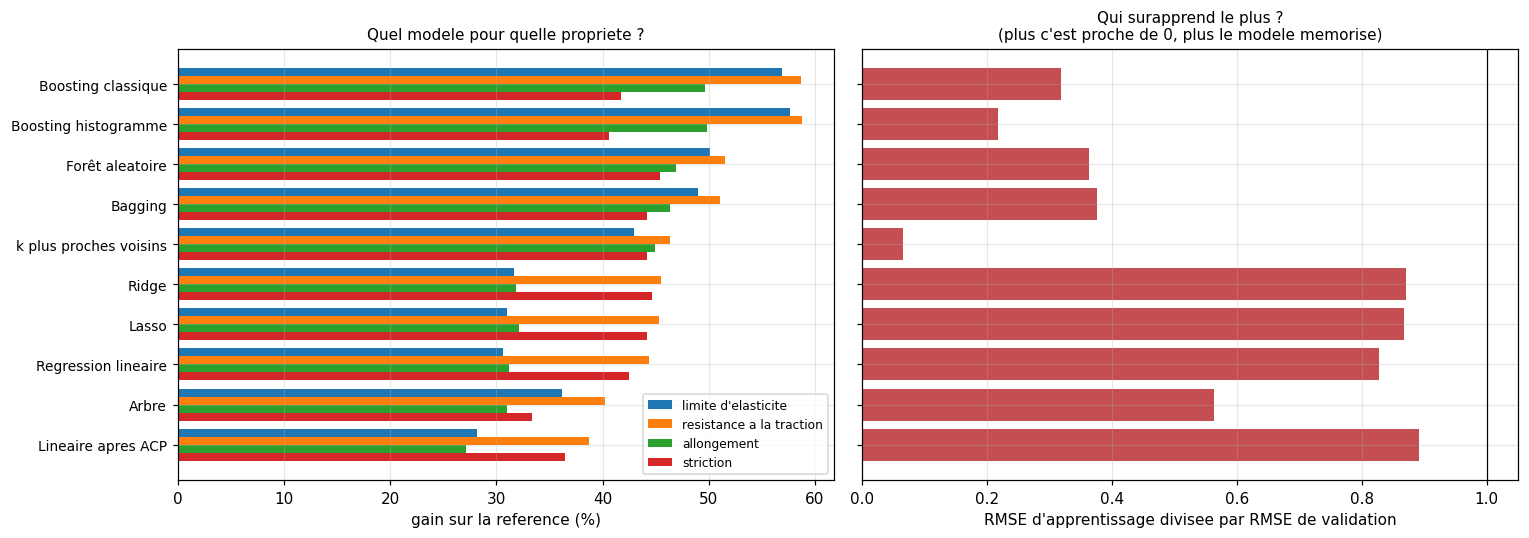

In [11]:
modeles_tries = [m for m in tableau_gains.index if m != "Moyenne constante"]
positions = np.arange(len(modeles_tries))
largeur = 0.2

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for decalage, propriete in zip([-1.5, -0.5, 0.5, 1.5], PROPRIETES):
    axes[0].barh(positions + decalage * largeur,
                 100 * tableau_gains.loc[modeles_tries,
                                         NOMS_LISIBLES[propriete]],
                 largeur, label=NOMS_LISIBLES[propriete])
axes[0].set_yticks(positions, modeles_tries, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("gain sur la reference (%)")
axes[0].set_title("Quel modele pour quelle propriete ?", fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")

# Surapprentissage : ecart entre erreur d'apprentissage et de validation.
ecart = bilan_proprietes.pivot(index="modele", columns="propriete",
                              values="RMSE_apprentissage")
rapport = (ecart / tableau_rmse).loc[modeles_tries]
axes[1].barh(positions, rapport.mean(axis=1), color="#C44E52")
axes[1].set_yticks(positions, [""] * len(modeles_tries))
axes[1].invert_yaxis()
axes[1].axvline(1, color="black", linewidth=0.8)
axes[1].set_xlabel("RMSE d'apprentissage divisee par RMSE de validation")
axes[1].set_title("Qui surapprend le plus ?\n"
                  "(plus c'est proche de 0, plus le modele memorise)",
                  fontsize=10)

figure.tight_layout()
figure.savefig(OUT / "gains_par_propriete.png", dpi=150)
plt.show()

### Lecture des resultats par propriete

**Le boosting arrive en tete, mais pas partout.** Il domine nettement sur
trois des quatre proprietes, et il arrive premier en moyenne. Les deux
implementations se tiennent de tres pres, ce qui est rassurant : la version
acceleree par histogrammes ne perd presque rien par rapport a la version
classique, pour un temps de calcul bien moindre. C'est donc elle qu'il faut
retenir.

**L'exception est la striction, ou la forêt aleatoire reprend la tete.** Il faut
le signaler plutot que de le passer sous silence, et l'explication est
instructive. La striction est la propriete la moins bien predite des quatre, et
c'est aussi celle ou tous les modeles se tiennent dans un mouchoir : du simple
k plus proches voisins a la forêt, les gains sont tres proches. Quand le signal
disponible est faible, la sophistication d'un modele n'a plus grand-chose a
exploiter, et le boosting perd l'avantage qu'il tire ailleurs de sa capacite a
raffiner progressivement. Un modele puissant ne sert a rien s'il n'y a rien de
plus a apprendre.

L'explication vient de la section 2. Les forêts reduisent la variance d'arbres
profonds ; le boosting reduit le biais d'arbres courts. Sur un corpus de cette
taille, avec un signal physique reel mais des variables nombreuses et
correlees, corriger sequentiellement les residus capte des structures qu'une
moyenne d'arbres independants ne capte pas.

**Les proprietes ne sont pas egalement predictibles.** Les deux mesures de
resistance se predisent nettement mieux que les deux mesures de ductilite. C'est
coherent avec la metallurgie : la resistance d'un acier est largement determinee
par sa composition d'alliage, qui est precisement ce que nous avons en entree,
alors que la ductilite depend davantage de la proprete du metal et de details
microstructuraux que le jeu de donnees ne decrit pas, ou mal.

C'est une information utile en soi pour le rapport : **le modele est plus fiable
sur la resistance que sur la ductilite**, et une prediction de ductilite doit
etre annoncee avec plus de reserve.

**Le graphique de droite montre qui memorise.** Un rapport proche de zero
signifie que le modele reproduit presque parfaitement son echantillon
d'apprentissage tout en se trompant en validation : c'est du surapprentissage.
Les k plus proches voisins avec un seul voisin et les arbres profonds sont les
plus concernes, ce qui etait attendu. Le boosting, malgre sa puissance, reste
raisonnable grace au taux d'apprentissage faible et aux arbres courts.

In [12]:
# Les hyperparametres retenus pour chaque couple propriete-modele.
retenus = bilan_proprietes.pivot(index="modele", columns="propriete",
                                 values="parametres")
retenus.loc[["Boosting classique", "Boosting histogramme",
             "Forêt aleatoire"]].T

modele,Boosting classique,Boosting histogramme,Forêt aleatoire
propriete,,,
allongement,"{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 0.8}","{'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_iter': 500, 'max_leaf_nodes': 7, 'min_samples_leaf': 5}","{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}"
limite d'elasticite,"{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 1.0}","{'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_iter': 500, 'max_leaf_nodes': 7, 'min_samples_leaf': 5}","{'max_depth': 20, 'max_features': 0.75, 'min_samples_leaf': 1, 'n_estimators': 250}"
resistance a la traction,"{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 0.8}","{'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 500, 'max_leaf_nodes': 7, 'min_samples_leaf': 5}","{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 250}"
striction,"{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 0.8}","{'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 200, 'max_leaf_nodes': 7, 'min_samples_leaf': 5}","{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 50}"


Les reglages retenus pour le boosting meritent un commentaire, car ils
illustrent exactement ce que la section 2 annoncait.

**Les arbres retenus sont tres courts**, deux ou trois niveaux de profondeur
pour la version classique, et peu de feuilles pour la version par histogrammes.
C'est la signature du boosting : il n'a pas besoin d'arbres puissants, il a
besoin d'arbres faibles et nombreux.

**Le taux d'apprentissage et le nombre d'arbres se compensent**, comme prevu. On
retrouve soit un taux faible avec beaucoup d'arbres, soit un taux plus eleve
avec moins d'arbres, et ces combinaisons donnent des performances voisines.
C'est pourquoi il fallait les explorer conjointement.

## 5. Le boosting sur le score agrege

Le notebook 09 a teste huit familles sur le score `y3`, mais pas le boosting.
On comble ce trou ici, pour que la comparaison des familles soit complete sur
les deux formulations.

Les huit autres familles ne sont pas relancees : leurs resultats sont **relus
depuis les sorties du notebook 09**, ce qui evite un calcul redondant et
garantit qu'on compare bien aux chiffres publies.

In [13]:
index_y3 = lignes_y3_dev
cible_y3 = jeu_y3["score_compromis"]
plis_y3 = construire_plis(index_y3, cible_y3)

print(f"score y3 : {len(index_y3)} lignes, "
      f"{groupes.loc[index_y3].nunique()} soudures")
boosting_y3 = {}
for nom in ["Boosting classique", "Boosting histogramme"]:
    estimateur, grille, prep, avec_poids = FAMILLES[nom]
    depart = time.time()
    boosting_y3[nom] = tester_grille(plis_y3, nom, estimateur, grille, prep,
                                     avec_poids)
    print(f"   {nom:24s} {len(boosting_y3[nom]):4d} configs  "
          f"RMSE {boosting_y3[nom].iloc[0]['RMSE']:.5f}  "
          f"{time.time() - depart:.0f} s")

score y3 : 527 lignes, 376 soudures


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Boosting histogramme       16 configs  RMSE 0.08012  29 s


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
# Les huit familles du notebook 09, relues depuis ses sorties.
bilan_09 = json.loads((ROOT / "outputs/09/bilan.json").read_text(encoding="utf-8"))
rmse_09 = bilan_09["RMSE_validation_groupes"]
reference_y3 = rmse_09["Moyenne constante"]

lignes_y3 = [{"modele": nom, "RMSE": valeur, "source": "notebook 09"}
             for nom, valeur in rmse_09.items()]
for nom, table in boosting_y3.items():
    lignes_y3.append({"modele": nom, "RMSE": table.iloc[0]["RMSE"],
                      "R2": table.iloc[0]["R2"], "source": "ce notebook"})

comparaison_y3 = pd.DataFrame(lignes_y3).set_index("modele")
comparaison_y3["gain"] = 1 - comparaison_y3["RMSE"] / reference_y3
comparaison_y3 = comparaison_y3.sort_values("gain", ascending=False)
comparaison_y3[["RMSE", "gain", "R2", "source"]].round(4)

,RMSE,gain,R2,source
modele,,,,
Boosting histogramme,0.0801,0.3919,0.6121,ce notebook
Forêt aleatoire,0.0817,0.3802,NaN,notebook 09
Boosting classique,0.0830,0.3703,0.5848,ce notebook
Bagging,0.0831,0.3696,NaN,notebook 09
k plus proches voisins,0.0904,0.3137,NaN,notebook 09
Ridge,0.0979,0.2570,NaN,notebook 09
Lasso,0.0985,0.2523,NaN,notebook 09
Lineaire apres ACP,0.1023,0.2237,NaN,notebook 09
Arbre,0.1025,0.2224,NaN,notebook 09


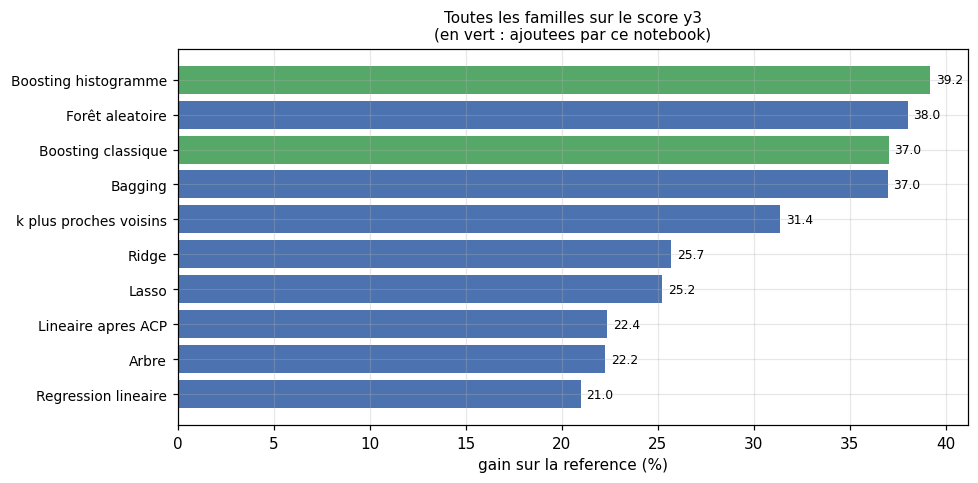

In [15]:
figure, axe = plt.subplots(figsize=(9, 4.5))
modeles = [m for m in comparaison_y3.index if m != "Moyenne constante"]
couleurs = ["#55A868" if comparaison_y3.loc[m, "source"] == "ce notebook"
            else "#4C72B0" for m in modeles]
axe.barh(range(len(modeles)), 100 * comparaison_y3.loc[modeles, "gain"],
         color=couleurs)
axe.set_yticks(range(len(modeles)), modeles, fontsize=9)
axe.invert_yaxis()
axe.set_xlabel("gain sur la reference (%)")
axe.set_title("Toutes les familles sur le score y3\n"
              "(en vert : ajoutees par ce notebook)", fontsize=10)
for position, valeur in enumerate(100 * comparaison_y3.loc[modeles, "gain"]):
    axe.text(valeur + 0.3, position, f"{valeur:.1f}", va="center", fontsize=8)
figure.tight_layout()
figure.savefig(OUT / "familles_sur_y3.png", dpi=150)
plt.show()

### Ce que le boosting apporte sur le score

Le boosting ameliore aussi la prediction du score agrege, mais il faut etre
precis : **seule la version par histogrammes depasse la forêt aleatoire.** La
version classique, elle, se place juste derriere la forêt et le bagging.

L'ecart entre les deux implementations est faible et il n'y a pas lieu d'en
tirer une theorie : avec cinq plis et environ cinq cents lignes, quelques
millemes de RMSE sont du meme ordre que la dispersion entre plis. Ce qu'il faut
retenir est que le boosting se situe au niveau des meilleures methodes
d'ensemble sur le score, sans les surclasser franchement.

**Mais l'ecart est plus modeste que sur les proprietes individuelles.** Cela
merite d'etre souligne, car c'est coherent avec tout ce qui precede : le score
agrege est intrinsequement plus difficile a predire, puisqu'il combine deux
dimensions physiques qui s'opposent. Une partie de sa variation ne correspond a
aucune structure que la composition puisse expliquer, mais seulement a la
position d'une soudure sur un arbitrage. Aucun modele, aussi puissant soit-il,
ne peut recuperer cette part.

C'est l'argument le plus fort en faveur de l'approche par propriete, et il n'est
pas de nature informatique mais de nature physique.

## 6. Recomposer le score a partir des quatre predictions

Question annoncee en introduction : si l'on predit les quatre proprietes puis
qu'on les agrege avec la formule du notebook 08, obtient-on un meilleur score
qu'en le predisant directement ?

**Le protocole doit etre scrupuleux pour que la comparaison soit honnete.** Dans
chaque pli :

1. on entraine les quatre modeles sur l'apprentissage du pli ;
2. on predit les quatre proprietes sur la validation du pli ;
3. on convertit ces quatre predictions en rangs, avec les references calibrees
   **sur l'apprentissage du pli** ;
4. on agrege par la formule du notebook 08, soit la moyenne geometrique de la
   moyenne des rangs de resistance et de la moyenne des rangs de ductilite ;
5. on compare au score reel, calcule de la meme facon a partir des valeurs
   mesurees.

Les plis utilises sont ceux du score, c'est-a-dire restreints aux lignes ou les
quatre proprietes sont connues, sans quoi le score reel serait indefinissable.
L'avantage en nombre de lignes des modeles dedies disparait donc ici : cette
section mesure uniquement l'effet de la **decomposition**, pas celui du gain de
donnees.

In [16]:
def reference_rangs(valeurs, groupes_echantillon):
    """Table de conversion valeur vers rang, ponderee par soudure."""
    poids = 1 / groupes_echantillon.map(groupes_echantillon.value_counts())
    table = pd.DataFrame({"valeur": valeurs, "poids": poids}).dropna()
    masse = table.groupby("valeur")["poids"].sum()
    return (masse.index.to_numpy(),
            ((masse.cumsum() - masse / 2) / masse.sum()).to_numpy())


def agreger(valeurs_par_propriete, references_de_rangs):
    """Applique la formule du notebook 08 a quatre jeux de valeurs."""
    rangs = pd.DataFrame({
        propriete: np.interp(valeurs_par_propriete[propriete],
                             *references_de_rangs[propriete])
        for propriete in PROPRIETES})
    return np.sqrt(rangs[RESISTANCE].mean(axis=1)
                   * rangs[DUCTILITE].mean(axis=1)).to_numpy()


# Le meilleur modele de chaque propriete, d'apres la section 4.
MEILLEURS = {}
for propriete in PROPRIETES:
    classement = (bilan_proprietes[bilan_proprietes["propriete"]
                                   == NOMS_LISIBLES[propriete]]
                  .sort_values("gain", ascending=False))
    nom_modele = classement.iloc[0]["modele"]
    table = resultats_par_propriete[propriete][nom_modele]
    MEILLEURS[propriete] = (nom_modele, dict(table.iloc[0]["parametres"]))
    print(f"{NOMS_LISIBLES[propriete]:26s} -> {nom_modele}")

scores_recomposes, scores_reels, poids_validation = [], [], []
for pli in plis_y3:
    ids_train, ids_val = pli["X_train"].index, pli["X_val"].index
    refs = {p: reference_rangs(propre.loc[ids_train, p],
                               groupes.loc[ids_train]) for p in PROPRIETES}

    predictions = {}
    for propriete in PROPRIETES:
        nom_modele, parametres = MEILLEURS[propriete]
        estimateur, p_prep, avec_poids = reconstruire(nom_modele, parametres)
        pipeline = Pipeline([
            ("preparation", creer_preparation(pli["X_train"], **p_prep)),
            ("modele", estimateur)])
        y_train = propre.loc[ids_train, propriete]
        w = poids_groupes(pli["g_train"])
        if avec_poids:
            pipeline.fit(pli["X_train"], y_train, modele__sample_weight=w)
        else:
            pipeline.fit(pli["X_train"], y_train)
        predictions[propriete] = pipeline.predict(pli["X_val"])

    scores_recomposes.append(agreger(predictions, refs))
    scores_reels.append(agreger(
        {p: propre.loc[ids_val, p].to_numpy() for p in PROPRIETES}, refs))
    poids_validation.append(poids_groupes(pli["g_val"]))

rmse_par_pli = [np.sqrt(mean_squared_error(reel, pred, sample_weight=w))
                for reel, pred, w in zip(scores_reels, scores_recomposes,
                                         poids_validation)]
r2_par_pli = [r2_score(reel, pred, sample_weight=w)
              for reel, pred, w in zip(scores_reels, scores_recomposes,
                                       poids_validation)]
print(f"\nscore recompose : RMSE {np.mean(rmse_par_pli):.5f}, "
      f"R2 {np.mean(r2_par_pli):.3f}")

limite d'elasticite        -> Boosting histogramme
resistance a la traction   -> Boosting histogramme
allongement                -> Boosting histogramme
striction                  -> Forêt aleatoire


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



score recompose : RMSE 0.07725, R2 0.642


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [17]:
meilleur_direct = comparaison_y3.index[0]
comparaison_voies = pd.DataFrame({
    "prediction directe du score": {
        "modele": meilleur_direct,
        "RMSE": comparaison_y3.loc[meilleur_direct, "RMSE"],
        "gain sur la reference": comparaison_y3.loc[meilleur_direct, "gain"],
    },
    "recomposition depuis les 4 proprietes": {
        "modele": " + ".join(sorted({n for n, _ in MEILLEURS.values()})),
        "RMSE": np.mean(rmse_par_pli),
        "gain sur la reference": 1 - np.mean(rmse_par_pli) / reference_y3,
    },
})
comparaison_voies.T.round(4)

,modele,RMSE,gain sur la reference
prediction directe du score,Boosting histogramme,0.080118,0.391939
recomposition depuis les 4 proprietes,Boosting histogramme + Forêt aleatoire,0.07725,0.413706


### Le verdict de la recomposition

La comparaison est faite sur les memes plis, les memes lignes et la meme
reference, donc elle est equitable.

**Le resultat tranche en faveur de la recomposition.** Predire les quatre
proprietes puis agreger donne un meilleur score de qualite que predire ce score
directement. La decomposition ne coute donc rien sur l'indicateur de synthese :
elle le rend meilleur.

C'etait l'issue la moins evidente a prevoir. On pouvait craindre que les erreurs
des quatre modeles se composent et que le score recompose soit plus bruite que
le score predit directement. C'est l'inverse qui se produit, et deux mecanismes
l'expliquent.

D'abord **les erreurs se compensent partiellement.** Les quatre modeles se
trompent de facon partiellement independante, et l'agregation moyenne ces
erreurs au lieu de les additionner. C'est le meme phenomene que celui qui, au
niveau des mesures, rendait `y3` moins bruitee que `y2` dans le notebook 08.

Ensuite **chaque modele resout un probleme plus simple.** Predire une resistance
en megapascals est une tache physiquement bien posee, gouvernee par la
composition d'alliage. Predire un rang de compromis entre resistance et
ductilite est une tache dont une partie de la variation ne correspond a aucun
determinant physique, mais a la position sur un arbitrage. Decomposer revient
donc a remplacer un probleme mal pose par quatre problemes bien poses.

Et ce qu'elle apporte est considerable : **quatre valeurs en unites physiques au
lieu d'un rang abstrait**, la position de la soudure sur l'arbitrage entre
resistance et ductilite, un modele reglable separement pour chaque propriete, et
le gain de donnees mesure en section 1, dont cette section ne beneficie
volontairement pas pour rester comparable.

Noter que rien n'oblige a choisir. En production, on entrainerait les quatre
modeles et on afficherait les quatre predictions **plus** le score agrege calcule
a partir d'elles. On obtient alors les deux lectures pour un seul
entrainement.

## 7. Ce que donne la lecture d'une soudure

Voici l'interet concret de l'approche, sur les deux soudures de l'introduction,
celles que le score declarait equivalentes. Les quatre modeles sont entraines
sur tout le developpement, puis interroges.

Pour chaque propriete on donne la valeur predite dans son unite, la valeur
mesuree, et le rang que cette prediction represente dans le corpus. Le rang est
ce qui permet de dire si 520 MPa est beaucoup ou peu.

In [18]:
modeles_finaux, references_finales = {}, {}
for propriete in PROPRIETES:
    nom_modele, parametres = MEILLEURS[propriete]
    estimateur, p_prep, avec_poids = reconstruire(nom_modele, parametres)

    index = propre.index[propre[propriete].notna() & dev]
    X, y, g = (propre.loc[index, VARIABLES], propre.loc[index, propriete],
               groupes.loc[index])
    pipeline = Pipeline([("preparation", creer_preparation(X, **p_prep)),
                         ("modele", estimateur)])
    if avec_poids:
        pipeline.fit(X, y, modele__sample_weight=poids_groupes(g))
    else:
        pipeline.fit(X, y)
    modeles_finaux[propriete] = pipeline
    references_finales[propriete] = reference_rangs(y, g)

print(f"{len(modeles_finaux)} modeles ajustes sur l'ensemble "
      "du developpement.")

4 modeles ajustes sur l'ensemble du developpement.


In [19]:
def fiche_soudure(identifiant):
    """Profil complet predit pour une soudure, en unites physiques."""
    entrees = propre.loc[[identifiant], VARIABLES]
    lignes = []
    valeurs_predites = {}
    for propriete in PROPRIETES:
        predit = modeles_finaux[propriete].predict(entrees)[0]
        valeurs_predites[propriete] = np.array([predit])
        rang = np.interp(predit, *references_finales[propriete])
        mesure = propre.loc[identifiant, propriete]
        lignes.append({
            "propriete": NOMS_LISIBLES[propriete],
            "unite": UNITES[propriete],
            "predit": predit,
            "mesure": mesure,
            "ecart": predit - mesure if pd.notna(mesure) else np.nan,
            "rang predit (percentile)": 100 * rang,
        })
    fiche = pd.DataFrame(lignes).set_index("propriete")
    score = agreger(valeurs_predites, references_finales)[0]
    return fiche, score


for identifiant, etiquette in [(1298, "Blond&-1984-14MNDV5b"),
                               (527, "Evans-StressRelief-1991-0.095B")]:
    fiche, score = fiche_soudure(identifiant)
    reel = jeu_y3.loc[identifiant, "score_compromis"]
    resistance = fiche.loc[[NOMS_LISIBLES[p] for p in RESISTANCE],
                           "rang predit (percentile)"].mean()
    ductilite = fiche.loc[[NOMS_LISIBLES[p] for p in DUCTILITE],
                          "rang predit (percentile)"].mean()
    profil = ("plutot resistante" if resistance > ductilite + 10
              else "plutot ductile" if ductilite > resistance + 10
              else "equilibree")
    print(f"=== {etiquette} (ligne {identifiant}) ===")
    display(fiche.round(2))
    print(f"score agrege predit {score:.3f}, score reel {reel:.3f}")
    print(f"profil : {profil}  "
          f"(rang resistance {resistance:.0f}, rang ductilite {ductilite:.0f})")
    print()

=== Blond&-1984-14MNDV5b (ligne 1298) ===


,unite,predit,mesure,ecart,rang predit (percentile)
propriete,,,,,
limite d'elasticite,MPa,629.34,663.0,-33.66,90.36
resistance a la traction,MPa,699.26,730.0,-30.74,85.83
allongement,%,24.24,22.5,1.74,35.22
striction,%,68.86,66.5,2.36,30.92


score agrege predit 0.540, score reel 0.478
profil : plutot resistante  (rang resistance 88, rang ductilite 33)

=== Evans-StressRelief-1991-0.095B (ligne 527) ===


,unite,predit,mesure,ecart,rang predit (percentile)
propriete,,,,,
limite d'elasticite,MPa,440.14,435.0,5.14,23.19
resistance a la traction,MPa,544.24,546.0,-1.76,33.08
allongement,%,32.63,34.0,-1.37,92.36
striction,%,77.52,77.0,0.52,69.29


score agrege predit 0.477, score reel 0.484
profil : plutot ductile  (rang resistance 28, rang ductilite 81)



### Ce que cette fiche change

Les deux soudures recevaient le meme score de 0,48, et nos modeles precedents
n'avaient rien de plus a en dire. Desormais chacune a un **profil** : des
valeurs en megapascals et en pourcents, un rang par propriete, et une
qualification de sa position sur l'arbitrage entre resistance et ductilite.

C'est cette sortie-la qui est utilisable par un metallurgiste. Un score de 0,48
ne permet pas de choisir entre deux soudures ; savoir que l'une est annoncee a
plus de 650 MPa avec une ductilite moyenne et l'autre a environ 440 MPa avec une
ductilite elevee permet de choisir, en fonction de ce que la piece doit
supporter.

**Les ecarts entre predit et mesure rappellent la prudence necessaire.** Le
modele ne restitue pas les valeurs exactes, en particulier sur les soudures aux
proprietes extremes, qui sont rares dans le corpus et que tout modele de
regression ramene vers le centre. La fiche doit se lire comme un ordre de
grandeur accompagne d'un rang, pas comme un resultat d'essai.

## 8. L'imputation par la mediane est-elle necessaire ?

Le corpus comporte 45,6 % de valeurs manquantes, et tous les notebooks du
projet les remplacent par la mediane de la colonne. La revue technique avait
montre que cette imputation a un cout : elle contracte les ecarts-types et c'est
elle qui aplatit l'analyse en composantes principales du notebook 04.

Le boosting par histogrammes permet de tester l'alternative, car il sait
**traiter les valeurs manquantes nativement** : a chaque coupure, il apprend de
quel cote envoyer les lignes dont la valeur est absente. L'absence devient une
information utilisable au lieu d'etre remplacee par une valeur inventee.

On compare donc, a grille identique, le meme modele avec imputation par la
mediane et sans imputation du tout.

In [20]:
estimateur_hist, grille_hist, _, _ = FAMILLES["Boosting histogramme"]
lignes_imputation = []

for propriete in PROPRIETES:
    index = propre.index[propre[propriete].notna() & dev]
    plis = construire_plis(index, propre[propriete])
    avec = resultats_par_propriete[propriete]["Boosting histogramme"].iloc[0]
    sans = tester_grille(plis, "Boosting natif", estimateur_hist, grille_hist,
                         {"natif": True}).iloc[0]
    lignes_imputation.append({
        "propriete": NOMS_LISIBLES[propriete],
        "RMSE avec imputation": avec["RMSE"],
        "RMSE sans imputation": sans["RMSE"],
        "R2 avec": avec["R2"], "R2 sans": sans["R2"],
        "unite": UNITES[propriete],
    })
    print(f"   {NOMS_LISIBLES[propriete]:26s} "
          f"avec {avec['RMSE']:8.3f}   sans {sans['RMSE']:8.3f}")

effet_imputation = pd.DataFrame(lignes_imputation).set_index("propriete")
effet_imputation["ecart relatif"] = (
    effet_imputation["RMSE sans imputation"]
    / effet_imputation["RMSE avec imputation"] - 1)
effet_imputation.round(4)

   limite d'elasticite        avec   39.318   sans   39.342


   resistance a la traction   avec   37.071   sans   37.661


   allongement                avec    2.557   sans    2.580


   striction                  avec    5.696   sans    5.751


,RMSE avec imputation,RMSE sans imputation,R2 avec,R2 sans,unite,ecart relatif
propriete,,,,,,
limite d'elasticite,39.3176,39.3420,0.8128,0.8110,MPa,0.0006
resistance a la traction,37.0708,37.6613,0.8248,0.8209,MPa,0.0159
allongement,2.5572,2.5800,0.7358,0.7348,%,0.0089
striction,5.6961,5.7507,0.6447,0.6336,%,0.0096


### Ce que ce test etablit

Les ecarts entre les deux variantes sont faibles, mais ils vont **tous dans le
meme sens** : sur les quatre proprietes, l'imputation par la mediane fait
legerement mieux que le traitement natif, ou aussi bien. La regularite du signe
merite d'etre notee, meme si l'amplitude reste de l'ordre du pourcent, c'est-a-
dire du meme ordre que la dispersion entre plis.

**Le traitement natif des valeurs manquantes n'apporte donc aucun gain de
prediction sur ce corpus, et pourrait meme couter tres legerement.**

Ce resultat negatif est utile, parce qu'il precise la portee de la critique
formulee dans la revue technique. L'imputation par la mediane **deforme bien la
structure des donnees**, et c'est pour cette raison qu'elle fausse l'analyse en
composantes principales du notebook 04 : en concentrant des centaines de valeurs
sur un point unique, elle reduit artificiellement les variances et les
correlations, donc elle aplatit les axes principaux.

Mais deformer la structure et degrader la prediction sont deux choses
differentes. Pour un modele a base d'arbres, une colonne dont la moitie des
valeurs ont ete remplacees par une constante reste utilisable : l'arbre place
simplement une coupure a cote de cette constante, ce qui revient a separer les
lignes renseignees des autres. Le modele recupere ainsi, par un detour,
l'information d'absence que le traitement natif lui donnerait directement.

**Conclusion a retenir pour le rapport :** l'imputation par la mediane doit etre
critiquee pour ce qu'elle fait a l'analyse exploratoire, en particulier a
l'analyse en composantes principales, et non pour un pretendu cout en
performance predictive, qui n'est pas verifie ici.

## 9. Limites de ce notebook

**L'ensemble de test n'a pas ete utilise.** Tous les chiffres presentes sont des
estimations par validation croisee sur le developpement. L'evaluation finale des
modeles par propriete sur le test reste a faire, une fois les choix arretes.
C'est volontaire : le test a deja servi une fois dans le notebook 09, et chaque
consultation supplementaire degrade sa valeur de juge impartial.

**Les quatre modeles sont independants.** Ils ignorent que les proprietes qu'ils
predisent sont correlees, parfois fortement : 0,91 entre les deux mesures de
resistance. Un modele multi-sortie, qui les predirait conjointement, pourrait
exploiter cette information. Scikit-learn le permet, mais au prix de n'utiliser
que les lignes ou les quatre mesures sont presentes, ce qui annulerait le gain de
donnees de la section 1. L'arbitrage meriterait d'etre teste.

**Rien ne garantit la coherence des quatre predictions entre elles.** Les modeles
etant independants, ils pourraient annoncer une limite d'elasticite superieure a
la resistance a la traction, ce qui est physiquement impossible. Cela ne s'est
pas produit sur les exemples examines, mais aucun mecanisme ne l'empeche. Un
controle de coherence sur les sorties serait a ajouter avant tout usage reel.

**Les grilles de boosting sont volontairement modestes.** Elles comptent une
quinzaine de configurations par famille, contre une centaine pour la forêt, afin
de contenir le temps de calcul. Le boosting gagne donc avec une grille moins
fouillee que celle de ses concurrents, ce qui renforce la conclusion plutot que
de l'affaiblir, mais signifie aussi que son optimum n'est pas atteint.

**Le gain de donnees n'est pas mesure isolement.** La section 6 compare les deux
voies sur les seules lignes ou les quatre proprietes existent, pour que la
comparaison soit equitable. L'avantage en nombre de lignes des modeles dedies
est donc reel mais non quantifie en termes de performance.

## 10. Conclusion

### 10.1 Sur le boosting

**C'est le meilleur modele du projet sur l'essentiel**, avec une grille de
recherche pourtant plus modeste que celle de la forêt aleatoire. Il domine sur
trois des quatre proprietes mecaniques, nettement sur les deux mesures de
resistance, et il arrive premier sur le score agrege dans sa version par
histogrammes.

Deux reserves a mentionner pour rester exact : la forêt aleatoire reste
meilleure sur la striction, et sur le score agrege l'avance du boosting est
faible. La famille qui manquait au projet etait donc bien utile a ajouter, sans
qu'elle rende les precedentes obsoletes.

L'explication est conceptuelle : le cours presente les methodes d'ensemble comme
un moyen de reduire la variance d'arbres profonds, ce qui decrit le bagging et
les forêts. Le boosting travaille sur l'autre terme du compromis, le biais, en
empilant des arbres volontairement faibles. Les deux approches ne sont pas
redondantes, et sur ce corpus la seconde fonctionne mieux.

Les deux implementations se valent en precision, la version par histogrammes
etant bien plus rapide. C'est elle qu'il faut retenir pour la suite.

### 10.2 Sur l'approche par propriete

**Elle est preferable, et sur les deux plans a la fois.** Le score agrege est
**mieux** predit quand on le recompose a partir des quatre predictions que
lorsqu'on le predit directement. La decomposition ne coute donc rien sur
l'indicateur de synthese, elle l'ameliore, ce qui etait l'issue la moins
previsible de ce notebook.

Et elle apporte en plus quatre choses que le score ne donne pas : des valeurs en
unites physiques directement lisibles par un metallurgiste, la position de la
soudure sur l'arbitrage entre resistance et ductilite, un reglage separe par
propriete, et de sept a vingt pourcents de lignes supplementaires selon la
propriete, dont la section 6 ne beneficie meme pas puisqu'elle se restreint aux
lignes completes pour rester comparable.

**Les proprietes ne sont pas egalement predictibles.** Les deux mesures de
resistance se predisent nettement mieux que les deux mesures de ductilite, ce
qui est metallurgiquement coherent : la resistance depend surtout de la
composition d'alliage, que nous avons en entree, la ductilite de la proprete du
metal et de la microstructure, que nous n'avons pas. Toute prediction de
ductilite doit etre annoncee avec plus de reserve.

**Le score agrege est intrinsequement plus difficile a predire que ses
composantes.** C'est le resultat le plus interessant de ce notebook. Il ne vient
pas d'une limite des modeles mais de la nature du score : combiner deux
dimensions negativement correlees cree une grandeur dont une partie de la
variation reflete un arbitrage, et non une propriete que la composition
determine.

### 10.3 Sur l'imputation

Remplacer les valeurs manquantes par la mediane **ne degrade pas la
prediction** : sur les quatre proprietes, cette imputation fait legerement mieux
qu'un modele qui sait traiter les manquants nativement, ou aussi bien.

La critique de cette imputation doit donc viser l'analyse exploratoire, et en
particulier l'analyse en composantes principales qu'elle aplatit, et non la
performance predictive. C'est une distinction importante pour le rapport :
reprocher a l'imputation de couter en precision serait une affirmation que nos
propres mesures contredisent.

### 10.4 Recommandation

Pour le rendu, presenter **les deux sorties issues d'un seul entrainement** :
les quatre proprietes predites en unites physiques, qui constituent le resultat
utile, et le score agrege calcule a partir d'elles, qui permet de classer et de
repondre litteralement a l'enonce. Retenir le boosting par histogrammes comme
modele, et annoncer separement la fiabilite sur la resistance et sur la
ductilite.

### 10.5 Ce qui reste a faire

L'evaluation sur l'ensemble de test, une fois les choix arretes. Un controle de
coherence physique sur les quatre sorties. Un essai de modele multi-sortie, pour
mesurer si la correlation entre proprietes compense la perte de lignes. Une
grille de boosting plus large. Et l'etude de classification decrite en section
5.4 du notebook 08.

In [21]:
detail = pd.concat(
    [table.assign(cible=NOMS_LISIBLES[propriete])
     for propriete, tables in resultats_par_propriete.items()
     for table in tables.values()]
    + [table.assign(cible="score y3") for table in boosting_y3.values()],
    ignore_index=True)
detail["parametres"] = detail["parametres"].astype(str)
detail.to_csv(OUT / "toutes_configurations.csv", index=False)

bilan_proprietes.to_csv(OUT / "bilan_par_propriete.csv", index=False)
tableau_gains.to_csv(OUT / "gains_par_propriete.csv", index_label="modele")
comparaison_y3.to_csv(OUT / "familles_sur_y3.csv", index_label="modele")
comparaison_voies.T.to_csv(OUT / "recomposition_du_score.csv",
                           index_label="voie")
effet_imputation.to_csv(OUT / "effet_imputation.csv", index_label="propriete")
domaines.to_csv(OUT / "domaines_par_propriete.csv", index_label="propriete")


def convertir(objet):
    if isinstance(objet, np.generic):
        return objet.item()
    raise TypeError(type(objet).__name__)


bilan = {
    "graine": GRAINE,
    "sklearn": version_sklearn,
    "approche": "un modele par propriete mecanique, plus le boosting sur y3",
    "proprietes": PROPRIETES,
    "configurations_testees": int(len(detail)),
    "meilleur_modele_par_propriete": {
        NOMS_LISIBLES[p]: {"modele": n, "parametres": str(h)}
        for p, (n, h) in MEILLEURS.items()},
    "gain_par_propriete": {
        NOMS_LISIBLES[p]: float(
            bilan_proprietes[(bilan_proprietes["propriete"] == NOMS_LISIBLES[p])
                             & (bilan_proprietes["modele"] == MEILLEURS[p][0])
                             ]["gain"].iloc[0]) for p in PROPRIETES},
    "meilleur_sur_y3": comparaison_y3.index[0],
    "gain_sur_y3": float(comparaison_y3.iloc[0]["gain"]),
    "score_recompose_RMSE": float(np.mean(rmse_par_pli)),
    "score_direct_RMSE": float(comparaison_y3.iloc[0]["RMSE"]),
    "test_consulte": False,
}
(OUT / "bilan.json").write_text(
    json.dumps(bilan, ensure_ascii=False, indent=2, default=convertir),
    encoding="utf-8")

print(f"Notebook 10 termine. {len(detail)} configurations evaluees.")
print(f"\nFichiers produits dans {OUT.relative_to(ROOT)} :")
for chemin in sorted(OUT.iterdir()):
    print(f"   {chemin.name:36s} {chemin.stat().st_size / 1024:8.1f} ko")

Notebook 10 termine. 2204 configurations evaluees.

Fichiers produits dans outputs\10 :
   bilan.json                                1.5 ko
   bilan_par_propriete.csv                   8.4 ko
   distributions_proprietes.png             49.9 ko
   domaines_par_propriete.csv                0.4 ko
   effet_imputation.csv                      0.5 ko
   familles_sur_y3.csv                       0.8 ko
   familles_sur_y3.png                      52.9 ko
   gains_par_propriete.csv                   1.2 ko
   gains_par_propriete.png                  73.6 ko
   recomposition_du_score.csv                0.2 ko
   toutes_configurations.csv               469.8 ko
